# XGBoost — CMVN Frame-Level Pipeline

Replaces the broken per-speaker MinMax normalisation with **CMVN applied per recording at frame level**, then trains XGBoost directly on the ~876k normalised frames.

Steps:
1. Load frame features (`stage_3_window_stats_filled.parquet`)
2. Apply CMVN per recording (removes speaker/channel DC offset)
3. Speaker-independent 70/15/15 split (stratified by language × gender)
4. Coarse → fine XGBoost hyperparameter search on a frame subsample (5-fold speaker-independent CV)
5. 10-fold speaker-independent CV with best params — report metrics per fold, frame, recording, language, gender
6. Held-out test set evaluation
7. Diagnostics and save

In [7]:
# =============================================================================
# Cell 1 — Imports & configuration
# =============================================================================
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import (
    RandomizedSearchCV, GridSearchCV, StratifiedGroupKFold, train_test_split
)
from xgboost import XGBRegressor

# --- Paths -------------------------------------------------------------------
BASE_DIR  = Path("/Users/patrycjamichniewska/Uni/Year 3/Thesis_local")
DATA_PATH = BASE_DIR / "data" / "stage_3_window_stats_filled.parquet"
META_PATH = BASE_DIR / "data" / "tesdhe_metadata.csv"
OUT_DIR   = BASE_DIR / "outputs" / "CMVN"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Reproducibility ---------------------------------------------------------
RANDOM_STATE = 42
TRAIN_SIZE   = 0.70
VAL_SIZE     = 0.15
TEST_SIZE    = 0.15

# --- CV / search config ------------------------------------------------------
N_FOLDS_SEARCH  = 5   # folds used during hyperparameter search
N_FOLDS_EVAL    = 10  # folds used for final evaluation CV
N_FRAMES_SEARCH = 30  # frames sampled per recording for search subsample
N_ITER          = 30  # coarse random search iterations

# Columns that are identifiers, target, or metadata — never features
NON_FEATURE_COLS = {"file_name", "frame_idx", "bpm"}
META_COLS_EXCL   = {"speaker_id", "language", "gender", "age_years"}

pd.set_option("display.float_format", "{:.4f}".format)
print("Config loaded.")

Config loaded.


In [8]:
# =============================================================================
# Cell 2 — Load frame-level data & attach metadata
# =============================================================================
frames = pd.read_parquet(DATA_PATH)
meta   = pd.read_csv(META_PATH)

print(f"Frames shape  : {frames.shape}")
print(f"Metadata shape: {meta.shape}")

meta_cols = meta[["file_name", "speaker_id", "language", "gender", "age_years"]].drop_duplicates("file_name")
frames = frames.merge(meta_cols, on="file_name", how="left")

n_null = frames["speaker_id"].isna().sum()
assert n_null == 0, f"{n_null} frames have no speaker_id after merge"

print(f"\nAfter metadata merge: {frames.shape}")
print(f"Unique recordings : {frames['file_name'].nunique()}")
print(f"Unique speakers   : {frames['speaker_id'].nunique()}")
print(f"BPM range         : {frames['bpm'].min()} – {frames['bpm'].max()}")

Frames shape  : (1252312, 95)
Metadata shape: (10034, 13)

After metadata merge: (1252312, 99)
Unique recordings : 10034
Unique speakers   : 109
BPM range         : 48 – 178


In [9]:
# =============================================================================
# Cell 3 — CMVN per recording
#
# Applies z-score normalisation (mean subtraction + std division) to each
# acoustic feature independently, grouped by recording.  This removes the
# per-recording speaker/channel DC offset while preserving temporal dynamics.
# Metadata columns (speaker_id, language, gender, age_years) are excluded.
# =============================================================================
FEATURE_COLS = [
    c for c in frames.columns
    if c not in NON_FEATURE_COLS and c not in META_COLS_EXCL
]

print(f"Acoustic feature columns : {len(FEATURE_COLS)}")
print(f"Excluded (non-feature)   : {NON_FEATURE_COLS}")
print(f"Excluded (metadata)      : {META_COLS_EXCL}")

# CMVN: per-recording z-score (acoustic features only)
frames[FEATURE_COLS] = (
    frames.groupby("file_name")[FEATURE_COLS]
    .transform(lambda x: (x - x.mean()) / max(float(x.std(ddof=0)), 1e-8))
)

# Constant features within a recording produce NaN after /std; fill with 0
n_inf = np.isinf(frames[FEATURE_COLS].values).sum()
frames[FEATURE_COLS] = frames[FEATURE_COLS].replace([np.inf, -np.inf], np.nan)
n_nan = frames[FEATURE_COLS].isna().sum().sum()
frames[FEATURE_COLS] = frames[FEATURE_COLS].fillna(0.0)
print(f"\nReplaced {n_inf} inf and {n_nan} NaN values with 0 after CMVN.")

# Sanity: spot-check per-recording mean ≈ 0, std ≈ 1
sample_recs = frames["file_name"].unique()[:3]
chk = (
    frames[frames["file_name"].isin(sample_recs)]
    .groupby("file_name")[FEATURE_COLS[:4]]
    .agg(["mean", "std"])
    .round(4)
)
print("\nPer-recording CMVN spot-check (first 4 features, 3 recordings):")
print(chk)

Acoustic feature columns : 92
Excluded (non-feature)   : {'file_name', 'frame_idx', 'bpm'}
Excluded (metadata)      : {'speaker_id', 'gender', 'age_years', 'language'}

Replaced 0 inf and 0 NaN values with 0 after CMVN.

Per-recording CMVN spot-check (first 4 features, 3 recordings):
                      mfcc_1         mfcc_2         mfcc_3         mfcc_4  \
                        mean    std    mean    std    mean    std    mean   
file_name                                                                   
En001M240401A083.ogg -0.0000 1.0165 -0.0000 1.0165  0.0000 1.0165  0.0000   
En001M240402A079.ogg -0.0000 1.0055 -0.0000 1.0055  0.0000 1.0055 -0.0000   
En001M240403A076.ogg  0.0000 1.0108 -0.0000 1.0108 -0.0000 1.0108  0.0000   

                             
                        std  
file_name                    
En001M240401A083.ogg 1.0165  
En001M240402A079.ogg 1.0055  
En001M240403A076.ogg 1.0108  


In [10]:
# =============================================================================
# Cell 4 — Speaker-independent 70 / 15 / 15 split (frame level)
# =============================================================================
speakers = (
    frames.groupby("speaker_id")
          .agg(language=("language", "first"),
               gender=("gender", "first"))
          .reset_index()
)
speakers["stratum"] = speakers["language"] + "_" + speakers["gender"]

train_spk, temp_spk = train_test_split(
    speakers,
    test_size=(VAL_SIZE + TEST_SIZE),
    stratify=speakers["stratum"],
    random_state=RANDOM_STATE,
)
val_spk, test_spk = train_test_split(
    temp_spk,
    test_size=TEST_SIZE / (VAL_SIZE + TEST_SIZE),
    stratify=temp_spk["stratum"],
    random_state=RANDOM_STATE,
)

frames = frames.merge(speakers[["speaker_id", "stratum"]], on="speaker_id", how="left")

train_mask = frames["speaker_id"].isin(train_spk["speaker_id"])
val_mask   = frames["speaker_id"].isin(val_spk["speaker_id"])
test_mask  = frames["speaker_id"].isin(test_spk["speaker_id"])

GROUP_COLS = ["file_name", "speaker_id", "language", "gender", "stratum"]

X_train      = frames.loc[train_mask, FEATURE_COLS].reset_index(drop=True)
y_train      = frames.loc[train_mask, "bpm"].reset_index(drop=True)
groups_train = frames.loc[train_mask, GROUP_COLS].reset_index(drop=True)

X_val        = frames.loc[val_mask, FEATURE_COLS].reset_index(drop=True)
y_val        = frames.loc[val_mask, "bpm"].reset_index(drop=True)
groups_val   = frames.loc[val_mask, GROUP_COLS].reset_index(drop=True)

X_test       = frames.loc[test_mask, FEATURE_COLS].reset_index(drop=True)
y_test       = frames.loc[test_mask, "bpm"].reset_index(drop=True)
groups_test  = frames.loc[test_mask, GROUP_COLS].reset_index(drop=True)

assert len(set(train_spk["speaker_id"]) & set(val_spk["speaker_id"])) == 0
assert len(set(train_spk["speaker_id"]) & set(test_spk["speaker_id"])) == 0
assert len(set(val_spk["speaker_id"])   & set(test_spk["speaker_id"])) == 0

print(f"Feature columns used (acoustic only, no metadata): {len(FEATURE_COLS)}")
print(f"  Sample: {FEATURE_COLS[:5]}")
print(f"\nSpeakers → train: {len(train_spk)}  val: {len(val_spk)}  test: {len(test_spk)}")
print(f"Frames   → train: {len(X_train)}  val: {len(X_val)}  test: {len(X_test)}")

Feature columns used (acoustic only, no metadata): 92
  Sample: ['mfcc_1', 'mfcc_2', 'mfcc_3', 'mfcc_4', 'mfcc_5']

Speakers → train: 76  val: 16  test: 17
Frames   → train: 890433  val: 153965  test: 207914


In [11]:
# =============================================================================
# Cell 5 — 5-fold search CV setup on a per-recording frame subsample
#
# Training all ~876k frames through 5-fold × 30-iter search would take hours.
# We subsample N_FRAMES_SEARCH frames per recording → ~214k frames for search.
# =============================================================================
search_idx = (
    groups_train
    .reset_index()          # preserves positional index as column 'index'
    .groupby("file_name", group_keys=False)
    .apply(lambda g: g.sample(min(N_FRAMES_SEARCH, len(g)), random_state=RANDOM_STATE))
    ["index"]
    .values
)

X_search      = X_train.iloc[search_idx].reset_index(drop=True)
y_search      = y_train.iloc[search_idx].reset_index(drop=True)
groups_search = groups_train.iloc[search_idx].reset_index(drop=True)

print(f"Search subsample: {len(X_search)} frames  "
      f"from {groups_search['file_name'].nunique()} recordings  "
      f"({groups_search['speaker_id'].nunique()} speakers)")

sgkf_search = StratifiedGroupKFold(
    n_splits=N_FOLDS_SEARCH, shuffle=True, random_state=RANDOM_STATE
)
cv_search_splits = list(
    sgkf_search.split(
        X_search,
        y=groups_search["stratum"].values,
        groups=groups_search["speaker_id"].values,
    )
)

print(f"\n=== Search CV fold sanity check ({N_FOLDS_SEARCH}-fold) ===")
for i, (tr_idx, va_idx) in enumerate(cv_search_splits, 1):
    tr_spk = set(groups_search.iloc[tr_idx]["speaker_id"])
    va_spk = set(groups_search.iloc[va_idx]["speaker_id"])
    print(
        f"Fold {i}: train spk={len(tr_spk):2d}  val spk={len(va_spk):2d}  "
        f"overlap={len(tr_spk & va_spk)}  val frames={len(va_idx)}"
    )

Search subsample: 213427 frames  from 7133 recordings  (76 speakers)

=== Search CV fold sanity check (5-fold) ===
Fold 1: train spk=62  val spk=14  overlap=0  val frames=41498
Fold 2: train spk=60  val spk=16  overlap=0  val frames=44305
Fold 3: train spk=59  val spk=17  overlap=0  val frames=46051
Fold 4: train spk=60  val spk=16  overlap=0  val frames=42672
Fold 5: train spk=63  val spk=13  overlap=0  val frames=38901


In [12]:
# =============================================================================
# Cell 6 — Coarse RandomizedSearchCV
# =============================================================================
coarse_distributions = {
    "n_estimators":     [200, 400, 600, 800, 1000],
    "max_depth":        [3, 5, 7, 9, 11],
    "learning_rate":    [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":        [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 7],
    "reg_alpha":        [0, 0.1, 1.0],
    "reg_lambda":       [1, 5, 10],
}

xgb_base = XGBRegressor(
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=1,
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=coarse_distributions,
    n_iter=N_ITER,
    scoring="neg_root_mean_squared_error",
    cv=cv_search_splits,
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=False,
)
random_search.fit(X_search, y_search)

best_coarse = random_search.best_params_
print(f"\nBest coarse RMSE (CV): {-random_search.best_score_:.3f}")
print(f"Best coarse params  : {best_coarse}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits


/Users/patrycjamichniewska/Uni/Year 3/Thesis_local/Thesis.env/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Best coarse RMSE (CV): 18.121
Best coarse params  : {'subsample': 0.8, 'reg_lambda': 5, 'reg_alpha': 0.1, 'n_estimators': 800, 'min_child_weight': 3, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}


In [13]:
# =============================================================================
# Cell 7 — Fine GridSearchCV around the coarse winner
# =============================================================================
def neighbours(value, candidates):
    candidates = sorted(set(candidates))
    idx = candidates.index(value)
    return candidates[max(0, idx - 2) : min(len(candidates), idx + 2)]

fine_grid = {
    "n_estimators":     neighbours(best_coarse["n_estimators"],
                                   coarse_distributions["n_estimators"]),
    "max_depth":        neighbours(best_coarse["max_depth"],
                                   coarse_distributions["max_depth"]),
    "learning_rate":    neighbours(best_coarse["learning_rate"],
                                   coarse_distributions["learning_rate"]),
    "subsample":        [best_coarse["subsample"]],
    "colsample_bytree": [best_coarse["colsample_bytree"]],
    "min_child_weight": [best_coarse["min_child_weight"]],
    "reg_alpha":        [best_coarse["reg_alpha"]],
    "reg_lambda":       [best_coarse["reg_lambda"]],
}
print("Fine grid (varied params):",
      {k: v for k, v in fine_grid.items() if len(v) > 1})

grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=fine_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv_search_splits,
    n_jobs=-1,
    verbose=1,
    refit=True,
)
grid_search.fit(X_search, y_search)

best_params = grid_search.best_params_
print(f"\nBest fine RMSE (CV): {-grid_search.best_score_:.3f}")
print(f"Best fine params   : {best_params}")

Fine grid (varied params): {'n_estimators': [400, 600, 800, 1000], 'max_depth': [3, 5, 7], 'learning_rate': [0.01, 0.03]}
Fitting 5 folds for each of 24 candidates, totalling 120 fits

Best fine RMSE (CV): 18.118
Best fine params   : {'colsample_bytree': 0.6, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 1000, 'reg_alpha': 0.1, 'reg_lambda': 5, 'subsample': 0.8}


In [14]:
# =============================================================================
# Cell 8 — 10-fold speaker-independent evaluation CV (all 109 speakers)
#
# Trains XGBoost with best_params in each of 10 folds.  Groups = speaker_id
# ensures no speaker bleeds between train and val within any fold.
# Reports per-fold frame-level and recording-level metrics.
# =============================================================================
X_all      = pd.concat([X_train, X_val, X_test], ignore_index=True)
y_all      = pd.concat([y_train, y_val, y_test], ignore_index=True)
groups_all = pd.concat([groups_train, groups_val, groups_test], ignore_index=True)
strata_all = groups_all["stratum"].values

print(f"Full dataset: {len(X_all)} frames  "
      f"{groups_all['file_name'].nunique()} recordings  "
      f"{groups_all['speaker_id'].nunique()} speakers")

sgkf_eval = StratifiedGroupKFold(
    n_splits=N_FOLDS_EVAL, shuffle=True, random_state=RANDOM_STATE
)

fold_results  = []
all_rec_preds = []

for fold_i, (tr_idx, va_idx) in enumerate(
    sgkf_eval.split(X_all, strata_all, groups_all["speaker_id"].values), 1
):
    X_tr = X_all.iloc[tr_idx].values
    y_tr = y_all.iloc[tr_idx].values
    X_va = X_all.iloc[va_idx].values
    y_va = y_all.iloc[va_idx].values
    meta_va = groups_all.iloc[va_idx].reset_index(drop=True)

    # Verify speaker independence
    tr_spk = set(groups_all.iloc[tr_idx]["speaker_id"])
    va_spk = set(groups_all.iloc[va_idx]["speaker_id"])
    assert len(tr_spk & va_spk) == 0, f"Fold {fold_i}: speaker overlap!"

    model = XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    model.fit(X_tr, y_tr)
    frame_preds = model.predict(X_va)

    # Dummy baseline (mean of fold training labels)
    dummy_rmse = float(np.sqrt(mean_squared_error(y_va, np.full_like(y_va, y_tr.mean()))))

    # Frame-level metrics
    frame_rmse = float(np.sqrt(mean_squared_error(y_va, frame_preds)))
    frame_mae  = float(mean_absolute_error(y_va, frame_preds))
    frame_r2   = float(r2_score(y_va, frame_preds))

    # Recording-level aggregation (mean frame prediction per recording)
    rec_df = meta_va.copy()
    rec_df["y_true"] = y_va
    rec_df["y_pred"] = frame_preds
    rec_agg = (
        rec_df.groupby("file_name")
        .agg(
            y_true=("y_true", "first"),
            y_pred=("y_pred", "mean"),
            language=("language", "first"),
            gender=("gender", "first"),
            speaker_id=("speaker_id", "first"),
        )
        .reset_index()
    )
    rec_agg["fold"] = fold_i

    rec_rmse = float(np.sqrt(mean_squared_error(rec_agg["y_true"], rec_agg["y_pred"])))
    rec_mae  = float(mean_absolute_error(rec_agg["y_true"], rec_agg["y_pred"]))
    rec_r2   = float(r2_score(rec_agg["y_true"], rec_agg["y_pred"]))

    fold_results.append({
        "fold":       fold_i,
        "n_frames":   len(va_idx),
        "n_recs":     len(rec_agg),
        "frame_rmse": frame_rmse,
        "frame_mae":  frame_mae,
        "frame_r2":   frame_r2,
        "rec_rmse":   rec_rmse,
        "rec_mae":    rec_mae,
        "rec_r2":     rec_r2,
        "dummy_rmse": dummy_rmse,
    })
    all_rec_preds.append(rec_agg)

    print(
        f"Fold {fold_i:2d}: frames={len(va_idx):6d}  recs={len(rec_agg):4d}  "
        f"frame RMSE={frame_rmse:.3f} R²={frame_r2:.3f}  "
        f"rec RMSE={rec_rmse:.3f} R²={rec_r2:.3f}  "
        f"baseline={dummy_rmse:.3f}"
    )

fold_df    = pd.DataFrame(fold_results)
all_rec_df = pd.concat(all_rec_preds, ignore_index=True)
print(f"\nAll folds done. Total val frames: {fold_df['n_frames'].sum()}")

Full dataset: 1252312 frames  10034 recordings  109 speakers
Fold  1: frames=122303  recs= 909  frame RMSE=13.038 R²=0.009  rec RMSE=14.472 R²=0.007  baseline=13.133
Fold  2: frames=120838  recs= 969  frame RMSE=16.752 R²=-0.125  rec RMSE=18.627 R²=-0.156  baseline=17.272
Fold  3: frames=127641  recs=1064  frame RMSE=17.400 R²=-0.132  rec RMSE=17.701 R²=-0.125  baseline=17.218
Fold  4: frames=124428  recs= 931  frame RMSE=13.398 R²=-0.040  rec RMSE=14.573 R²=-0.046  baseline=13.331
Fold  5: frames=122724  recs=1105  frame RMSE=22.132 R²=-0.042  rec RMSE=22.213 R²=-0.019  baseline=22.382
Fold  6: frames=129039  recs=1034  frame RMSE=14.530 R²=-0.164  rec RMSE=15.021 R²=-0.126  baseline=14.781
Fold  7: frames=129781  recs=1097  frame RMSE=17.267 R²=-0.019  rec RMSE=18.237 R²=-0.024  baseline=17.268
Fold  8: frames=124082  recs= 975  frame RMSE=15.034 R²=-0.001  rec RMSE=15.464 R²=0.005  baseline=15.033
Fold  9: frames=121512  recs= 974  frame RMSE=15.324 R²=-0.002  rec RMSE=16.362 R²=-0.

In [15]:
# =============================================================================
# Cell 9 — Aggregate CV metrics
# =============================================================================
def metrics_block(y_true, y_pred, label=""):
    n    = len(y_true)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred)) if n > 1 else float("nan")
    tag  = f"[{label}] " if label else ""
    print(f"{tag}n={n:5d}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}")
    return {"n": n, "RMSE": rmse, "MAE": mae, "R2": r2}

# --- Per-fold table ---
print("=== Per-fold metrics ===")
print(fold_df.to_string(index=False, float_format="{:.3f}".format))

# --- Mean ± std across folds ---
print("\n=== CV mean ± std across 10 folds ===")
for col in ["frame_rmse", "frame_mae", "frame_r2", "rec_rmse", "rec_mae", "rec_r2"]:
    print(f"  {col:15s}: {fold_df[col].mean():.3f} ± {fold_df[col].std():.3f}")

# --- Pooled recording-level (all folds concatenated) ---
print("\n=== Pooled recording-level metrics (all folds) ===")
pooled_metrics = metrics_block(all_rec_df["y_true"], all_rec_df["y_pred"], "Overall")

# --- By language ---
print("\n--- By language ---")
lang_metrics = {}
for lang, grp in all_rec_df.groupby("language"):
    lang_metrics[lang] = metrics_block(grp["y_true"], grp["y_pred"], f"language={lang}")

# --- By gender ---
print("\n--- By gender ---")
gender_metrics = {}
for gender, grp in all_rec_df.groupby("gender"):
    gender_metrics[gender] = metrics_block(grp["y_true"], grp["y_pred"], f"gender={gender}")

agg_metrics = {
    "overall": pooled_metrics,
    "by_language": lang_metrics,
    "by_gender": gender_metrics,
    "fold_mean_frame_rmse": float(fold_df["frame_rmse"].mean()),
    "fold_std_frame_rmse":  float(fold_df["frame_rmse"].std()),
    "fold_mean_rec_rmse":   float(fold_df["rec_rmse"].mean()),
    "fold_std_rec_rmse":    float(fold_df["rec_rmse"].std()),
    "mean_dummy_rmse":      float(fold_df["dummy_rmse"].mean()),
}

=== Per-fold metrics ===
 fold  n_frames  n_recs  frame_rmse  frame_mae  frame_r2  rec_rmse  rec_mae  rec_r2  dummy_rmse
    1    122303     909      13.038      8.814     0.009    14.472    9.910   0.007      13.133
    2    120838     969      16.752     12.463    -0.125    18.627   13.848  -0.156      17.272
    3    127641    1064      17.400     14.316    -0.132    17.701   14.431  -0.125      17.218
    4    124428     931      13.398     10.842    -0.040    14.573   11.785  -0.046      13.331
    5    122724    1105      22.132     15.504    -0.042    22.213   15.974  -0.019      22.382
    6    129039    1034      14.530     10.527    -0.164    15.021   10.732  -0.126      14.781
    7    129781    1097      17.267     14.140    -0.019    18.237   15.030  -0.024      17.268
    8    124082     975      15.034     12.531    -0.001    15.464   12.951   0.005      15.033
    9    121512     974      15.324     11.550    -0.002    16.362   12.348  -0.001      15.354
   10    129964

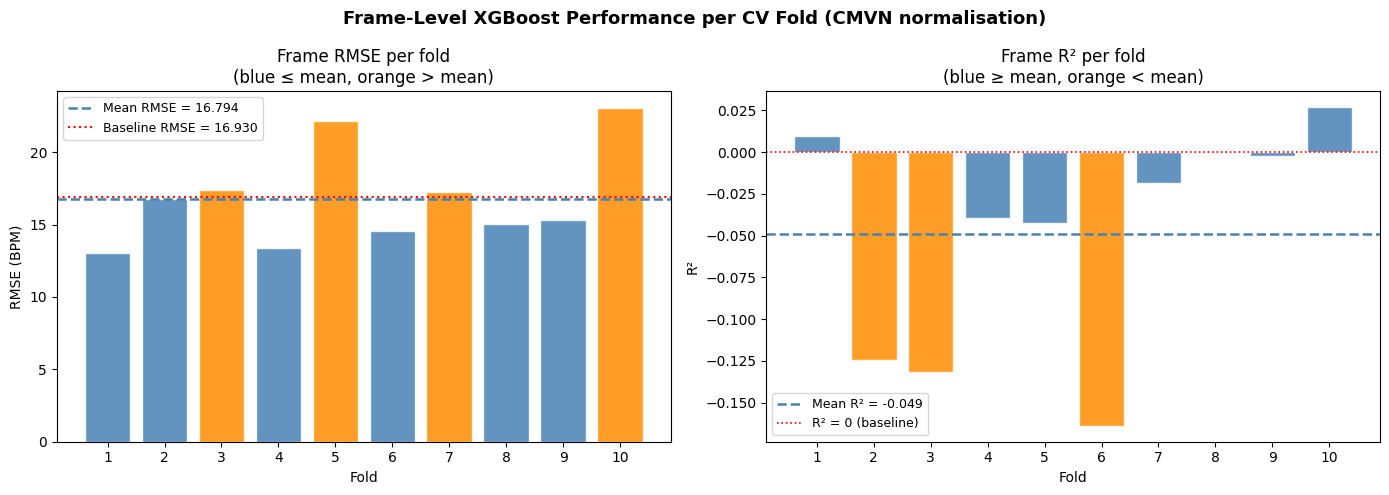

Saved → /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/CMVN/cv_frame_per_fold.png


In [16]:
# =============================================================================
# Cell 10 — Frame-level per-fold performance plot
# =============================================================================
mean_frame_rmse = fold_df["frame_rmse"].mean()
mean_frame_r2   = fold_df["frame_r2"].mean()
mean_dummy_rmse = fold_df["dummy_rmse"].mean()

folds = fold_df["fold"].values
colors_rmse = ["steelblue" if v <= mean_frame_rmse else "darkorange"
               for v in fold_df["frame_rmse"]]
colors_r2   = ["steelblue" if v >= mean_frame_r2 else "darkorange"
               for v in fold_df["frame_r2"]]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(
    "Frame-Level XGBoost Performance per CV Fold (CMVN normalisation)",
    fontsize=13, fontweight="bold"
)

ax1.bar(folds, fold_df["frame_rmse"], color=colors_rmse, alpha=0.85, edgecolor="white")
ax1.axhline(mean_frame_rmse, color="steelblue", lw=1.8, linestyle="--",
            label=f"Mean RMSE = {mean_frame_rmse:.3f}")
ax1.axhline(mean_dummy_rmse, color="red", lw=1.5, linestyle=":",
            label=f"Baseline RMSE = {mean_dummy_rmse:.3f}")
ax1.set_xlabel("Fold"); ax1.set_ylabel("RMSE (BPM)")
ax1.set_title("Frame RMSE per fold\n(blue ≤ mean, orange > mean)")
ax1.set_xticks(folds)
ax1.legend(fontsize=9)

ax2.bar(folds, fold_df["frame_r2"], color=colors_r2, alpha=0.85, edgecolor="white")
ax2.axhline(mean_frame_r2, color="steelblue", lw=1.8, linestyle="--",
            label=f"Mean R² = {mean_frame_r2:.3f}")
ax2.axhline(0, color="red", lw=1.2, linestyle=":", label="R² = 0 (baseline)")
ax2.set_xlabel("Fold"); ax2.set_ylabel("R²")
ax2.set_title("Frame R² per fold\n(blue ≥ mean, orange < mean)")
ax2.set_xticks(folds)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUT_DIR / "cv_frame_per_fold.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_DIR / 'cv_frame_per_fold.png'}")

In [17]:
# =============================================================================
# Cell 11 — Held-out test set evaluation
#
# Final model trained on all training speakers (76 speakers, full frames).
# =============================================================================
final_model = XGBRegressor(
    **best_params,
    objective="reg:squarederror",
    tree_method="hist",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
final_model.fit(X_train.values, y_train.values)

test_frame_preds = final_model.predict(X_test.values)

# Baseline
dummy_test = DummyRegressor(strategy="mean")
dummy_test.fit(X_train.values, y_train.values)
test_dummy_preds = dummy_test.predict(X_test.values)

print("=== Held-out test set — frame level ===")
print("Baseline :", end=" "); metrics_block(y_test.values, test_dummy_preds)
metrics_block(y_test.values, test_frame_preds, "XGBoost")

# Recording-level aggregation
test_rec = groups_test.copy()
test_rec["y_true"] = y_test.values
test_rec["y_pred"] = test_frame_preds
test_rec_agg = (
    test_rec.groupby("file_name")
    .agg(y_true=("y_true", "first"), y_pred=("y_pred", "mean"),
         language=("language", "first"), gender=("gender", "first"))
    .reset_index()
)

print("\n=== Held-out test set — recording level ===")
test_metrics = {"overall": metrics_block(test_rec_agg["y_true"],
                                           test_rec_agg["y_pred"], "Overall")}
for col in ["language", "gender"]:
    print(f"\n--- By {col} ---")
    test_metrics[col] = {}
    for level, grp in test_rec_agg.groupby(col):
        test_metrics[col][level] = metrics_block(
            grp["y_true"], grp["y_pred"], f"{col}={level}"
        )

=== Held-out test set — frame level ===
Baseline : n=207914  RMSE=14.246  MAE=10.720  R²=-0.000
[XGBoost] n=207914  RMSE=14.330  MAE=10.779  R²=-0.012

=== Held-out test set — recording level ===
[Overall] n= 1570  RMSE=15.620  MAE=11.912  R²=0.010

--- By language ---
[language=English] n=  785  RMSE=17.741  MAE=13.012  R²=-0.026
[language=Tamil] n=  785  RMSE=13.161  MAE=10.811  R²=-0.141

--- By gender ---
[gender=F] n=  571  RMSE=18.873  MAE=14.739  R²=-0.008
[gender=M] n=  999  RMSE=13.411  MAE=10.295  R²=-0.029


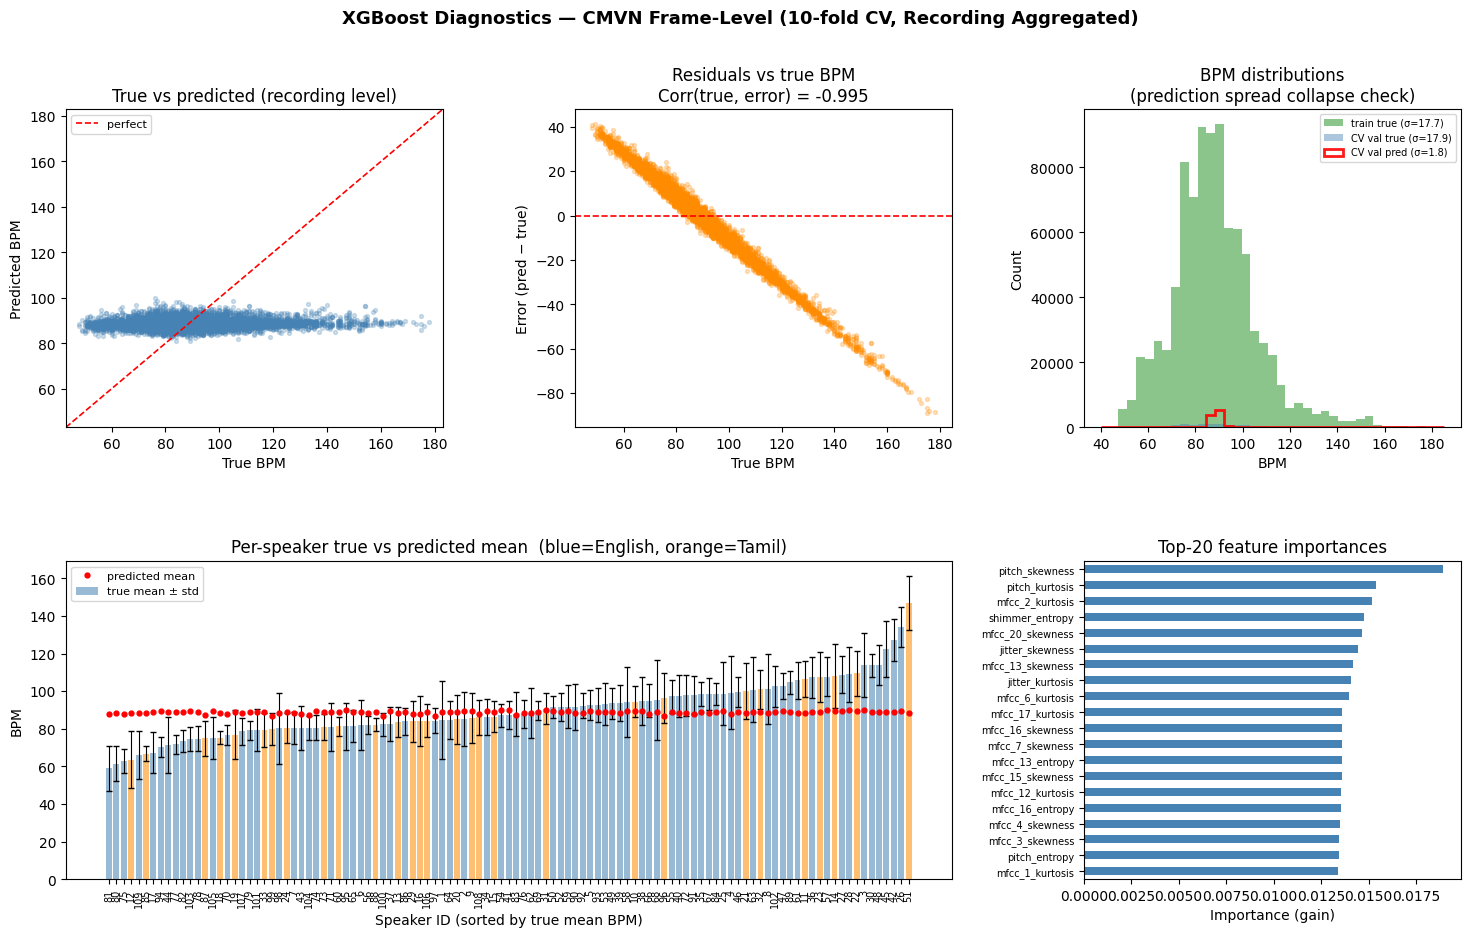


                                      RMSE        R²
Train (frame)                       15.034     0.281
CV frame (mean±std across folds)    16.794±3.407    -0.049±0.067
CV recording (pooled)               17.804     0.006

std(y_pred_rec) = 1.81 BPM  (was 6.04 BPM with per-speaker MinMax)
Corr(y_true, y_pred) = 0.081
Saved → /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/CMVN/xgb_cmvn_diagnostics.png


In [18]:
# =============================================================================
# Cell 12 — Diagnostics (pooled 10-fold CV recording-level predictions)
# =============================================================================
y_true_rec = all_rec_df["y_true"].values
y_pred_rec = all_rec_df["y_pred"].values
errors_rec = y_pred_rec - y_true_rec

y_train_pred_frame = final_model.predict(X_train.values)
train_rmse = float(np.sqrt(mean_squared_error(y_train.values, y_train_pred_frame)))
train_r2   = float(r2_score(y_train.values, y_train_pred_frame))

fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    "XGBoost Diagnostics — CMVN Frame-Level (10-fold CV, Recording Aggregated)",
    fontsize=13, fontweight="bold"
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

# (0,0) True vs predicted scatter
ax = fig.add_subplot(gs[0, 0])
ax.scatter(y_true_rec, y_pred_rec, alpha=0.25, s=8, color="steelblue")
lims = [min(float(y_true_rec.min()), float(y_pred_rec.min())) - 5,
        max(float(y_true_rec.max()), float(y_pred_rec.max())) + 5]
ax.plot(lims, lims, "r--", lw=1.2, label="perfect")
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel("True BPM"); ax.set_ylabel("Predicted BPM")
ax.set_title("True vs predicted (recording level)")
ax.legend(fontsize=8)

# (0,1) Residuals vs true BPM
ax = fig.add_subplot(gs[0, 1])
ax.scatter(y_true_rec, errors_rec, alpha=0.25, s=8, color="darkorange")
ax.axhline(0, color="red", lw=1.2, linestyle="--")
corr_err = float(np.corrcoef(y_true_rec, errors_rec)[0, 1])
ax.set_xlabel("True BPM"); ax.set_ylabel("Error (pred − true)")
ax.set_title(f"Residuals vs true BPM\nCorr(true, error) = {corr_err:.3f}")

# (0,2) BPM distributions — check for prediction spread collapse
ax = fig.add_subplot(gs[0, 2])
bins = np.linspace(40, 185, 40)
ax.hist(y_train.values, bins=bins, alpha=0.45,
        label=f"train true (σ={y_train.std():.1f})", color="green")
ax.hist(y_true_rec, bins=bins, alpha=0.45,
        label=f"CV val true (σ={y_true_rec.std():.1f})", color="steelblue")
ax.hist(y_pred_rec, bins=bins, alpha=0.9,
        label=f"CV val pred (σ={y_pred_rec.std():.1f})",
        color="red", histtype="step", linewidth=2)
ax.set_xlabel("BPM"); ax.set_ylabel("Count")
ax.set_title("BPM distributions\n(prediction spread collapse check)")
ax.legend(fontsize=7)

# (1,0:2) Per-speaker true vs predicted mean
ax = fig.add_subplot(gs[1, :2])
spk_sum = (
    all_rec_df.groupby("speaker_id")
    .agg(true_mean=("y_true", "mean"), pred_mean=("y_pred", "mean"),
         true_std=("y_true", "std"),   language=("language", "first"))
    .sort_values("true_mean")
)
x = np.arange(len(spk_sum))
colors = ["steelblue" if l == "English" else "darkorange"
          for l in spk_sum["language"]]
ax.bar(x, spk_sum["true_mean"], yerr=spk_sum["true_std"], alpha=0.55,
       color=colors, error_kw=dict(elinewidth=0.8, capsize=2),
       label="true mean ± std")
ax.plot(x, spk_sum["pred_mean"], "r.", ms=7, zorder=5, label="predicted mean")
ax.set_xticks(x)
ax.set_xticklabels(spk_sum.index.astype(str), rotation=90, fontsize=7)
ax.set_xlabel("Speaker ID (sorted by true mean BPM)")
ax.set_ylabel("BPM")
ax.set_title("Per-speaker true vs predicted mean  (blue=English, orange=Tamil)")
ax.legend(fontsize=8)

# (1,2) Top-20 feature importances from final model
ax = fig.add_subplot(gs[1, 2])
fi = pd.Series(final_model.feature_importances_,
               index=FEATURE_COLS).nlargest(20).sort_values()
fi.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Importance (gain)")
ax.set_title("Top-20 feature importances")
ax.tick_params(axis="y", labelsize=7)

plt.savefig(OUT_DIR / "xgb_cmvn_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

cv_rec_rmse = float(np.sqrt(mean_squared_error(y_true_rec, y_pred_rec)))
cv_rec_r2   = float(r2_score(y_true_rec, y_pred_rec))
print(f"\n{'':32s}  {'RMSE':>8}  {'R²':>8}")
print(f"{'Train (frame)':32s}  {train_rmse:8.3f}  {train_r2:8.3f}")
print(f"{'CV frame (mean±std across folds)':32s}  "
      f"{fold_df['frame_rmse'].mean():8.3f}±{fold_df['frame_rmse'].std():.3f}  "
      f"{fold_df['frame_r2'].mean():8.3f}±{fold_df['frame_r2'].std():.3f}")
print(f"{'CV recording (pooled)':32s}  {cv_rec_rmse:8.3f}  {cv_rec_r2:8.3f}")
print(f"\nstd(y_pred_rec) = {y_pred_rec.std():.2f} BPM  "
      f"(was 6.04 BPM with per-speaker MinMax)")
print(f"Corr(y_true, y_pred) = {float(np.corrcoef(y_true_rec, y_pred_rec)[0,1]):.3f}")
print(f"Saved → {OUT_DIR / 'xgb_cmvn_diagnostics.png'}")

In [19]:
# =============================================================================
# Cell 13 — Save outputs
# =============================================================================
final_model.save_model(OUT_DIR / "xgb_cmvn_best.json")

with open(OUT_DIR / "xgb_cmvn_best_params.json", "w") as f:
    json.dump(best_params, f, indent=2, default=str)

fold_df.to_csv(OUT_DIR / "xgb_cmvn_cv_fold_metrics.csv", index=False)

with open(OUT_DIR / "xgb_cmvn_cv_agg_metrics.json", "w") as f:
    json.dump(agg_metrics, f, indent=2)

all_rec_df.to_csv(OUT_DIR / "xgb_cmvn_cv_predictions.csv", index=False)

with open(OUT_DIR / "xgb_cmvn_test_metrics.json", "w") as f:
    json.dump(test_metrics, f, indent=2)

print(f"Saved to {OUT_DIR}:")
for fname in [
    "xgb_cmvn_best.json", "xgb_cmvn_best_params.json",
    "xgb_cmvn_cv_fold_metrics.csv", "xgb_cmvn_cv_agg_metrics.json",
    "xgb_cmvn_cv_predictions.csv", "xgb_cmvn_test_metrics.json",
    "xgb_cmvn_diagnostics.png", "cv_frame_per_fold.png",
]:
    print(f"  {fname}")

Saved to /Users/patrycjamichniewska/Uni/Year 3/Thesis_local/outputs/CMVN:
  xgb_cmvn_best.json
  xgb_cmvn_best_params.json
  xgb_cmvn_cv_fold_metrics.csv
  xgb_cmvn_cv_agg_metrics.json
  xgb_cmvn_cv_predictions.csv
  xgb_cmvn_test_metrics.json
  xgb_cmvn_diagnostics.png
  cv_frame_per_fold.png
